In this notebook, I model my excitonic Hamiltonian as a Gaussian Unitary Ensemble (GUE) in order to shift to a more natural Hamiltonian and have a more holistic control knob for non-integrability.

The Hamiltonian will be block-diagonal in the particle-number sector where each diagonal block will be a GUE. The cavity coupling will appear as a block-offdiagonal matrix linking different particle sectors to one another. The goal is to see how g, dephasing times, and the ETH thermalization times depend on one another and use ETH phenonmenon to inform experimental coupling strengths.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from scipy.optimize import minimize_scalar
import matplotlib.cm as cm
import itertools
from itertools import combinations
from joblib import Parallel, delayed
import pickle

from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import root_scalar
from scipy.sparse.linalg import eigsh
from scipy.linalg import sqrtm
from scipy.sparse import csr_matrix, lil_matrix
from collections import defaultdict
from scipy.sparse.linalg import expm_multiply
from scipy.linalg import svd
from scipy.optimize import curve_fit
from scipy.optimize import brentq
from scipy.linalg import logm, sqrtm, expm
from qutip import *
from math import comb
import itertools
from scipy.integrate import solve_ivp

In [11]:
def generate_particle_basis(L, N):
    """All bitstrings of length L with exactly N ones (as ints)."""
    return [sum(1 << i for i in combo) for combo in itertools.combinations(range(L), N)]

def create_bosonic_H_GUE(L, num_particles=2, max_occupancy=None, scale=1.0, seed=None):
    """
    Create a Gaussian Unitary Ensemble (GUE) Hamiltonian in the bosonic basis.

    Parameters
    ----------
    L : int
        Number of lattice sites.
    num_particles : int
        Total number of bosons.
    max_occupancy : int or None
        Maximum occupancy per site (default: num_particles).
    scale : float
        Overall energy scale (sets the standard deviation of matrix elements).
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    H : np.ndarray
        Hermitian random matrix (GUE) of shape (dim, dim).
    basis : list of tuples
        Bosonic Fock basis in same ordering as the Hamiltonian.
    """
    rng = np.random.default_rng(seed)
    basis = generate_particle_basis(L, N=num_particles)
    dim = len(basis)

    # Generate a random complex matrix with independent Gaussian entries
    A = rng.normal(0, 1, (dim, dim)) + 1j * rng.normal(0, 1, (dim, dim))
    
    # Symmetrize to make it Hermitian (GUE condition)
    H = (A + A.conj().T) / 2.0

    # Normalize to desired scale (optional: ensure variance = scale^2 / dim)
    H *= scale / np.sqrt(dim)

    return H, basis

def reduced_density_matrix_general(rho, basis, keep_sites):
    """
    Optimized version of reduced_density_matrix_general that reduces memory and computational overhead.
    """
    dim_red = 2 ** len(keep_sites)
    rho_red = np.zeros((dim_red, dim_red), dtype=complex)

    # Precompute bit masks for keep sites
    keep_masks = [(1 << s) for s in keep_sites]
    trace_mask = sum(keep_masks)
    
    # Precompute index mapping
    index_map = {}
    for idx, state in enumerate(basis):
        keep_bits = [(state >> s) & 1 for s in keep_sites]
        red_idx = sum(b << i for i, b in enumerate(reversed(keep_bits)))
        trace_bits = state & ~trace_mask
        index_map[idx] = (trace_bits, red_idx)

    # Group by trace_bits
    groups = defaultdict(list)
    for idx, (trace_bits, _) in index_map.items():
        groups[trace_bits].append(idx)

    # Accumulate reduced density matrix elements
    for trace_bits, indices in groups.items():
        for i in indices:
            _, i_red = index_map[i]
            for j in indices:
                _, j_red = index_map[j]
                rho_red[i_red, j_red] += rho[i, j]

    return rho_red

# def fidelity(rho1, rho2):
#     sqrt_rho1 = sqrtm(rho1)
#     return np.real(np.trace(sqrtm(sqrt_rho1 @ rho2 @ sqrt_rho1))**2)

# def relative_entropy(rho1, rho2):
#     return np.trace(rho1 @ (logm(rho1) - logm(rho2))).real

# def trace_distance_calc(rho1, rho2):
#     diff = rho1 - rho2
#     s = svd(diff, compute_uv=False)
#     return 0.5 * np.sum(np.abs(s))

def thermal_expectation_Hamiltonian(beta, evals):
    
    e_min = np.min(beta * evals)        # Shift energies to avoid overflow: numerical trick
    weights = np.exp(-(beta * evals - e_min))  # shifted exponent
    Z = np.sum(weights)
    thermal_E = np.sum(evals * weights) / Z
    return thermal_E

def find_beta_with_neg_temps(H, psi0, bracket=(-500, 500), plot=False):
    """Finds beta ∈ (−∞, ∞) such that thermal energy = ⟨ψ0|H|ψ0⟩."""
    E = np.vdot(psi0, H @ psi0).real
    evals, _ = np.linalg.eigh(H)

    def f(beta):
        return thermal_expectation_Hamiltonian(beta, evals) - E

    f_lo = f(bracket[0])
    f_hi = f(bracket[1])

    if np.sign(f_lo) == np.sign(f_hi):
        if plot:
            import matplotlib.pyplot as plt
            beta_vals = np.linspace(bracket[0], bracket[1], 500)
            thermal_vals = [thermal_expectation_Hamiltonian(b, evals) for b in beta_vals]
            plt.plot(beta_vals, thermal_vals, label="⟨H⟩_thermal(β)")
            plt.axhline(E, color='r', linestyle='--', label="E_init")
            plt.xlabel("β")
            plt.ylabel("Energy")
            plt.legend()
            plt.title("No root found: energy outside thermal range")
            plt.show()
        raise RuntimeError("No root in bracket: energy outside accessible thermal range.")

    beta_star = brentq(f, *bracket, xtol=1e-10)
    print(f"beta_star = {beta_star}")
    return beta_star, E 

# -------------------------------------------------------------------------------------------
#               BLOCK DIAGONAL IDEA RELATED FUNCTIONS BELOW
# -------------------------------------------------------------------------------------------

def generate_particle_basis_for_N(L, N):
    """
    Generate all spatial configurations with exactly N particles on L sites.
    Returns as list of bitstrings (integers).
    """
    return [sum(1 << i for i in combo) for combo in itertools.combinations(range(L), N)]

def generate_full_basis_structured(L, max_N=2):
    """
    Generate basis organized by particle number sectors.
    
    Returns
    -------
    basis : list of int
        All basis states (as bitstrings)
    sector_dims : dict
        sector_dims[N] = (start_index, end_index, dimension)
    """
    basis = []
    sector_dims = {}
    
    for N in range(max_N + 1):
        start_idx = len(basis)
        sector_basis = generate_particle_basis_for_N(L, N)
        basis.extend(sector_basis)
        end_idx = len(basis)
        dim_N = end_idx - start_idx
        
        sector_dims[N] = (start_idx, end_idx, dim_N)
        
        print(f"N={N} sector: dimension = {dim_N} (expected: {comb(L, N)})")
        print(f"  Indices in full basis: [{start_idx}:{end_idx})")
        if N <= 1 or dim_N <= 5:  # Show states for small sectors
            print(f"  States (as bitstrings): {sector_basis[:5]}")
    
    total_dim = len(basis)
    print(f"\nTotal Hilbert space dimension: {total_dim}")
    print(f"  = sum of (L choose N) for N=0 to {max_N}")
    print(f"  = {' + '.join([f'C({L},{N})' for N in range(max_N+1)])}")
    print(f"  = {' + '.join([str(comb(L, N)) for N in range(max_N+1)])} = {total_dim}")
    
    return basis, sector_dims

def create_block_diagonal_GUE(L, basis, kappa, sector_dims, max_particles=2, scale=1.0, seed=None):
    """
    Create a block-diagonal GUE Hamiltonian with separate GUE for each particle sector.
    
    Parameters
    ----------
    L : int
        Number of lattice sites.
    max_particles : int
        Maximum number of particles (creates sectors N=0,1,...,max_particles).
    scale : float
        Overall energy scale (sets the standard deviation of matrix elements).
    seed : int or None
        Random seed for reproducibility.
    
    Returns
    -------
    H : np.ndarray
        Block-diagonal Hermitian random matrix (GUE) of shape (dim, dim).
    """
    rng = np.random.default_rng(seed)
    
    total_dim = len(basis)
    
    # Initialize the full Hamiltonian as zeros
    H = np.zeros((total_dim, total_dim), dtype=complex)
    
    start_idx = [0,0,0]
    end_idx = [0,0,0]
    dim_N = [0,0,0]

    # Fill each diagonal block with its own GUE
    for N in range(max_particles + 1):
        start_idx[N], end_idx[N], dim_N[N] = sector_dims[N]
        print(f"start_idx[{N}] = {start_idx[N]}")
        print(f"end_idx[{N}] = {end_idx[N]}")
        print(f"dim_N[{N}] = {dim_N[N]}")
        if dim_N[N] == 0:
            continue
        
        # Generate a random complex matrix with independent Gaussian entries
        A = rng.normal(0, 1, (dim_N[N], dim_N[N])) + 1j * rng.normal(0, 1, (dim_N[N], dim_N[N]))
        
        # Symmetrize to make it Hermitian (GUE condition)
        H_block = (A + A.conj().T) / 2.0
        
        # Normalize to desired scale
        H_block *= scale / np.sqrt(dim_N[N])
        print(f"Working right now in the N = {N} sector")
        # Place this GUE block in the diagonal of H
        H[start_idx[N]:end_idx[N], start_idx[N]:end_idx[N]] = H_block
        # if N == 1:
        #     H[start_idx[N]:end_idx[N], start_idx[0]] = kappa
        #     H[start_idx[0], start_idx[N]:end_idx[N]] = kappa

        if N == 2:
            H[start_idx[N]:end_idx[N], start_idx[0]] = kappa
            H[start_idx[0], start_idx[N]:end_idx[N]] = kappa
    
    return H

def sector_probabilities(psi, sector_dims):
    """
    Return dict: P[N] = probability weight of psi in the N-particle sector.
    psi must be full Hilbert-space vector (len = total_dim).
    """
    probs = {}
    norm = np.vdot(psi, psi).real
    if norm == 0:
        raise ValueError("psi has zero norm.")
    
    for N, (start, end, dim) in sector_dims.items():
        probs[N] = float(np.sum(np.abs(psi[start:end])**2) / norm)
    return probs

def dominant_sector(psi, sector_dims):
    probs = sector_probabilities(psi, sector_dims)
    N_star = max(probs, key=probs.get)
    return N_star, probs


def partial_trace_rho_bitbasis(rho, basis, L, keep_sites, normalize_trace=True):
    """
    Partial trace over sites not in keep_sites, assuming basis states are bitstrings.

    Parameters
    ----------
    rho : (D, D) complex ndarray
        Density matrix in the same ordering as `basis`.
    basis : list[int]
        Bitstrings for each basis vector, length D.
    L : int
        Total number of sites.
    keep_sites : list[int]
        Sites to keep (subsystem A), 0-based indices.
    normalize_trace : bool
        If True, normalize so Tr(rhoA)=1.

    Returns
    -------
    rhoA : (2^k, 2^k) complex ndarray
        Reduced density matrix on the kept sites in occupation basis.
        The local basis ordering uses keep_sites order: keep_sites[0] is the least-significant kept bit.
    """
    rho = np.asarray(rho, dtype=complex)
    basis = np.asarray(basis) if not isinstance(basis, np.ndarray) else basis
    
    keep_sites = list(keep_sites)
    k = len(keep_sites)
    dimA = 1 << k
    D = len(basis)

    # Bit masks
    maskA = sum(1 << s for s in keep_sites)
    maskAll = (1 << L) - 1
    maskB = maskAll ^ maskA

    # Compress full bitstring -> A-local index
    pos_in_A = {site: p for p, site in enumerate(keep_sites)}
    def compress_A(bits):
        a = 0
        for site in keep_sites:
            if (bits >> site) & 1:
                a |= (1 << pos_in_A[site])
        return a

    # Precompute a(i), b(i)
    a_of = np.empty(D, dtype=np.int64)
    b_of = np.empty(D, dtype=np.int64)
    for i, bits in enumerate(basis):
        a_of[i] = compress_A(bits)
        b_of[i] = bits & maskB

    # Group indices by same B configuration
    groups = defaultdict(list)
    for i, b in enumerate(b_of):
        groups[b].append(i)

    # rhoA[a,a'] = sum_b sum_{i,j in group(b)} rho[i,j] with a=a(i), a'=a(j)
    rhoA = np.zeros((dimA, dimA), dtype=complex)
    for idxs in groups.values():
        idxs = np.asarray(idxs, dtype=np.int64)
        a_idxs = a_of[idxs]
        block = rho[np.ix_(idxs, idxs)]  # (m, m)

        # accumulate block entries into rhoA using A-indices
        # (works even if multiple global states map to same local 'a')
        np.add.at(rhoA, (a_idxs[:, None], a_idxs[None, :]), block)

    if normalize_trace:
        tr = np.trace(rhoA)
        if abs(tr) > 0:
            rhoA /= tr

    return rhoA

def _herm(rho):
    """Hermitian symmetrization to clean up numerical noise."""
    return 0.5 * (rho + rho.conj().T)

def _logm_psd(rho, eps=1e-12):
    """
    Stable log for (approximately) PSD Hermitian matrices using eigen-decomposition.
    Clips eigenvalues below eps to avoid -inf and numerical blow-ups.
    """
    rho = _herm(rho)
    w, v = np.linalg.eigh(rho)
    w = np.clip(w.real, eps, None)
    return (v * np.log(w)) @ v.conj().T

def fidelity(rho1, rho2):
    """
    Uhlmann fidelity:
        F(rho1, rho2) = (Tr sqrt( sqrt(rho1) rho2 sqrt(rho1) ))^2
    Returns a float in [0, 1] up to numerical clipping.
    """
    rho1 = _herm(rho1)
    rho2 = _herm(rho2)

    sr1 = sqrtm(rho1)
    X = sr1 @ rho2 @ sr1
    X = _herm(X)  # clean up before sqrtm

    sX = sqrtm(X)
    tr = np.trace(sX)

    F = (tr * tr.conj()).real  # |Tr(...)|^2
    return float(np.clip(F, 0.0, 1.0))

def relative_entropy(rho1, rho2, eps=1e-12):
    """
    Quantum relative entropy:
        S(rho1 || rho2) = Tr[ rho1 (log rho1 - log rho2) ]
    Uses eigen-based log with eigenvalue clipping for stability.
    """
    rho1 = _herm(rho1)
    rho2 = _herm(rho2)

    log_rho1 = _logm_psd(rho1, eps=eps)
    log_rho2 = _logm_psd(rho2, eps=eps)

    S = np.trace(rho1 @ (log_rho1 - log_rho2)).real
    return float(max(S, 0.0))

def trace_distance_calc(rho1, rho2):
    """
    Trace distance:
        D(rho1, rho2) = 1/2 || rho1 - rho2 ||_1
    For Hermitian diff, ||.||_1 = sum |eigs|.
    """
    diff = _herm(rho1 - rho2)
    eigs = np.linalg.eigvalsh(diff)
    return float(0.5 * np.sum(np.abs(eigs)))

def damped_cosine(t, C, A, gamma, Omega, phi):
    return C + A * np.exp(-gamma * t) * np.cos(Omega * t + phi)

def estimate_Omega_from_fft(t, y):
    # crude initial guess for Omega (rad/time)
    y0 = y - np.mean(y)
    dt = t[1] - t[0]
    freqs = np.fft.rfftfreq(len(t), d=dt)          # cycles/time
    Y = np.abs(np.fft.rfft(y0))
    k = np.argmax(Y[1:]) + 1                       # ignore DC component
    return 2 * np.pi * freqs[k]                    # rad/time

def fit_decay_or_oscillation(t, y):
    # initial guesses
    C0 = y[-1]
    A0 = y[0] - C0
    gamma0 = 1.0 / max(t[-1], 1e-12)
    Omega0 = estimate_Omega_from_fft(t, y)         # will be ~0 if no oscillations
    phi0 = 0.0

    p0 = [C0, A0, gamma0, Omega0, phi0]

    # bounds: gamma >= 0, Omega >= 0
    bounds = ([-np.inf, -np.inf, 0.0, 0.0, -2*np.pi],
              [ np.inf,  np.inf, np.inf, np.inf,  2*np.pi])

    popt, pcov = curve_fit(damped_cosine, t, y, p0=p0, bounds=bounds, maxfev=20000)
    C, A, gamma, Omega, phi = popt

    # optional: goodness of fit
    resid = y - damped_cosine(t, *popt)
    rss = np.sum(resid**2)

    return {"C": C, "A": A, "gamma": gamma, "Omega": Omega, "phi": phi, "rss": rss}

def make_sz_dephasing_ops_only_N2(basis, sector_dims, L, gamma_phi, sites=None):
    """
    Build jump operators L_j = sqrt(gamma_phi) * (P2 * sz_j * P2),
    represented in the FULL basis (dimension len(basis)),
    but with nonzero entries ONLY on the N=2 sector indices.

    Since sz_j is diagonal in the bitstring basis, these L_j are diagonal too.
    """
    if sites is None:
        sites = list(range(L))

    D = len(basis)
    start2, end2, dim2 = sector_dims[2]
    idxs2 = range(start2, end2)

    L_ops = []
    for j in sites:
        diag = np.zeros(D, dtype=float)  # full dimension, but only fill N=2 block

        for i in idxs2:
            bits = basis[i]
            occ = (bits >> j) & 1
            diag[i] = 1.0 if occ else -1.0   # sigma^z eigenvalues in {|1>,|0>} convention

        L_j = np.diag(np.sqrt(gamma_phi) * diag).astype(complex)
        L_ops.append(L_j)

    return L_ops

def lindblad_rhs(tt, rho_vec, H, L_ops):
    # Ensure everything is a numpy array
    rho_vec = np.asarray(rho_vec, dtype=complex)
    H = np.asarray(H, dtype=complex)
    
    D = H.shape[0]
    rho = rho_vec.reshape((D, D))

    drho = -1j * (H @ rho - rho @ H)
    for Lk in L_ops:
        LdL = Lk.conj().T @ Lk
        drho += (Lk @ rho @ Lk.conj().T) - 0.5 * (LdL @ rho + rho @ LdL)

    return drho.reshape(-1)

def compute_metrics_dephasing(t, H, L_ops, rho0_vec, basis, L, keep_sites, rhoA_thermal):
    # Ensure ndarray (prevents the tuple-indexing list error downstream)
    H = np.asarray(H, dtype=complex)
    rho0_vec = np.asarray(rho0_vec, dtype=complex)
    basis = np.asarray(basis)

    sol = solve_ivp(
        fun=lambda tt, y: lindblad_rhs(tt, y, H, L_ops),
        t_span=(0.0, float(t)),
        y0=rho0_vec,
        t_eval=[float(t)],
        method="RK45",
        rtol=1e-7,
        atol=1e-9
    )
    if not sol.success:
        raise RuntimeError(sol.message)

    sol_y = np.asarray(sol.y)
    if sol_y.ndim == 1:
        # If 1D, this is already the solution at the single time point
        rho_vec_t = sol_y
    else:
        # If 2D, extract the last column
        rho_vec_t = sol_y[:, -1]
    D = H.shape[0]
    rho_full_t = rho_vec_t.reshape(D, D).astype(complex)

    rhoA_t = partial_trace_rho_bitbasis(
        rho_full_t, basis, L, keep_sites, normalize_trace=True
    )

    F = fidelity(rhoA_t, rhoA_thermal)
    D_val = trace_distance_calc(rhoA_t, rhoA_thermal)
    S = relative_entropy(rhoA_t, rhoA_thermal)

    return D_val, 1.0 - F, S, rho_full_t

def sector_probabilities_from_psi(psi, sector_dims):
    probs = {}
    for N, (s, e, _) in sector_dims.items():
        probs[N] = float(np.vdot(psi[s:e], psi[s:e]).real)
    return probs





ETH testing on 2-particle sector

In [4]:
# --- Setup ---
L = 50
keep_sites = keep_sites = [L//2, L//2 - 1, L//2 + 1]
t_max = 20
num_samples = 50
times = np.linspace(0, t_max, num_samples)

# --- Hamiltonian and initial state ---
H, basis = create_bosonic_H_GUE(L=L, num_particles=2)                
evals, evecs = np.linalg.eigh(H)
psi0 = np.zeros(len(basis), dtype=complex)
psi0[0] = 1.0
proj_psi0 = evecs.T.conj() @ psi0

# --- Thermal state and reduced version ---
beta_star, _ = find_beta_with_neg_temps(H, psi0, bracket=(-100, 100))
weights = np.exp(-beta_star * evals)
weights /= np.sum(weights)
rho_thermal_full = (evecs * weights[np.newaxis, :]) @ evecs.conj().T
red_rho_thermal = reduced_density_matrix_general(rho_thermal_full, basis, keep_sites)

# --- Function to compute observables at a single time ---
def compute_observables(t):
    psi_t = evecs @ (np.exp(-1j * evals * t) * proj_psi0)
    rho_t = np.outer(psi_t, psi_t.conj())
    red_rho_t = reduced_density_matrix_general(rho_t, basis, keep_sites)

    D = trace_distance_calc(red_rho_t, red_rho_thermal)
    F = fidelity(red_rho_t, red_rho_thermal)
    S = relative_entropy(red_rho_t, red_rho_thermal)
    return D, 1 - F, S

# --- Parallel execution ---
results = Parallel(n_jobs=-1)(delayed(compute_observables)(t) for t in times)

# --- Unpack results ---
trace_distances_plain, infidelities_plain, rel_entropies_plain = map(list, zip(*results))

# 4m 9.1s

beta_star = -0.017101172643405733


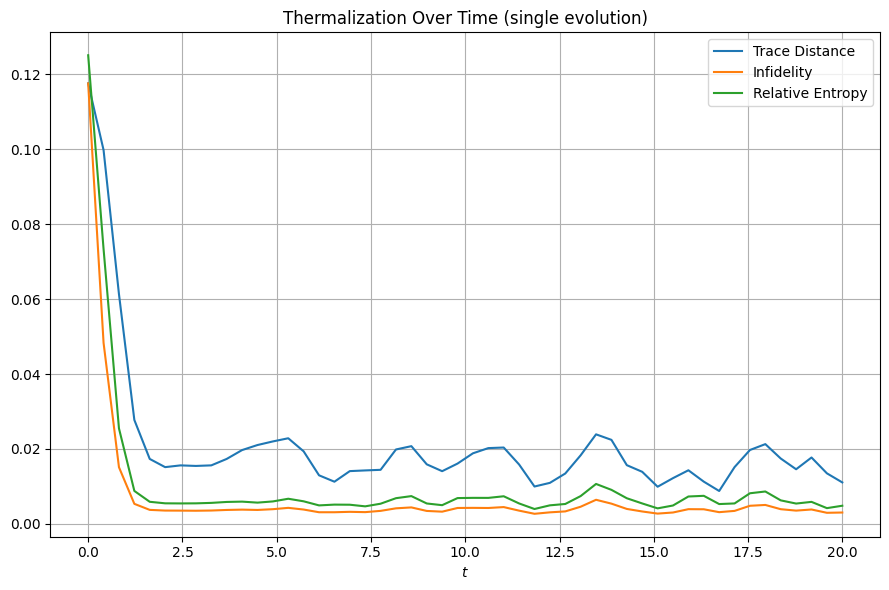

In [ ]:
# --- Plotting ---
plt.figure(figsize=(9, 6))
plt.plot(times, trace_distances_plain, label='Trace Distance')
plt.plot(times, infidelities_plain, label='Infidelity')
plt.plot(times, rel_entropies_plain, label='Relative Entropy')
plt.xlabel(r'$t$')
plt.title('Thermalization Over Time (single evolution)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Now generalizing this to 0-, 1-, 2-particle number sectors

<>:93: SyntaxWarning: invalid escape sequence '\k'
<>:93: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_978510/206721968.py:93: SyntaxWarning: invalid escape sequence '\k'
  plt.plot(times, D_all[i], label=f"$\kappa=${kappa}")


N=0 sector: dimension = 1 (expected: 1)
  Indices in full basis: [0:1)
  States (as bitstrings): [0]
N=1 sector: dimension = 50 (expected: 50)
  Indices in full basis: [1:51)
  States (as bitstrings): [1, 2, 4, 8, 16]
N=2 sector: dimension = 1225 (expected: 1225)
  Indices in full basis: [51:1276)

Total Hilbert space dimension: 1276
  = sum of (L choose N) for N=0 to 2
  = C(50,0) + C(50,1) + C(50,2)
  = 1 + 50 + 1225 = 1276
basis length = 1276

Basis structure:
N=0: basis[0:1] has 1 states
N=1: basis[1:51] has 50 states
N=2: basis[51:1276] has 1225 states
start_idx[0] = 0
end_idx[0] = 1
dim_N[0] = 1
Working right now in the N = 0 sector
start_idx[1] = 1
end_idx[1] = 51
dim_N[1] = 50
Working right now in the N = 1 sector
start_idx[2] = 51
end_idx[2] = 1276
dim_N[2] = 1225
Working right now in the N = 2 sector
beta_star = -0.01379617907833951
start_idx[0] = 0
end_idx[0] = 1
dim_N[0] = 1
Working right now in the N = 0 sector
start_idx[1] = 1
end_idx[1] = 51
dim_N[1] = 50
Working right n

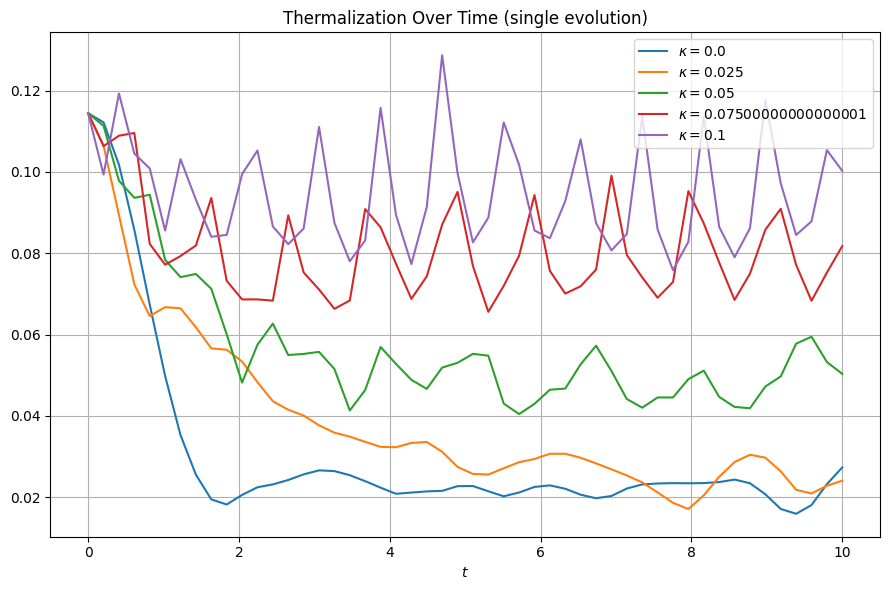

In [24]:
# Example 2: L=50, up to N=2 particles
L = 50
max_particles = 2
t_max = 10
num_samples = 50
times = np.linspace(0, t_max, num_samples)
basis, sector_dims = generate_full_basis_structured(L, max_N=max_particles)
print(f"basis length = {len(basis)}")
kappa_vals = np.linspace(0,0.1,5)     # N=0 to N=2 sector coupling constant/exchange interaction/hopping term
keep_sites = [L//2, L//2 - 1, L//2 + 1]
D_all = [0]*len(kappa_vals)
F_all = [0]*len(kappa_vals)
S_all = [0]*len(kappa_vals)
psi_t_all = [0]*len(kappa_vals)

print("\n" + "="*60)
print("Basis structure:")
print("="*60)

for N in range(max_particles+1):
    start, end, dim = sector_dims[N]
    print(f"N={N}: basis[{start}:{end}] has {dim} states")

# --- Function to compute observables at a single time ---

def compute_metrics(t):
    psi = evecs @ (np.exp(-1j * evals * t) * proj_psi0)
    rho_full_t = np.outer(psi, psi.conj())
    rhoA_t = partial_trace_rho_bitbasis(rho_full_t, basis, L, keep_sites, normalize_trace=True)

    F = fidelity(rhoA_t, rhoA_thermal)
    D = trace_distance_calc(rhoA_t, rhoA_thermal)
    S = relative_entropy(rhoA_t, rhoA_thermal)   # S(rhoA_t || rhoA_th)

    return D, 1-F, S, psi

for i, kappa in enumerate(kappa_vals):
    # --- Hamiltonian and initial state ---
    H = create_block_diagonal_GUE(L, basis, kappa, sector_dims = sector_dims, max_particles = max_particles)

    # # --- Initial state: 1 particle on first site (site index 0) ---
    # N = 1
    # start_1, end_1, dim_1 = sector_dims[N]
    # state_bit = 1 << 0 # particle on site 0
    # idx_in_sector = basis[start_1:end_1].index(state_bit)   # 0..dim_1-1
    # idx_full = start_1 + idx_in_sector  # index in the full basis list
    # psi0 = np.zeros(len(basis), dtype=complex)
    # psi0[idx_full] = 1.0

    # # --- Sanity checks ---
    # print("N=1 sector indices:", (start_1, end_1, dim_1))
    # print("Target bitstring:", state_bit, " (binary:", bin(state_bit), ")")
    # print("Index in N=1 sector:", idx_in_sector)
    # print("Index in full basis:", idx_full)

    # --- Initial state: 2 particles on first two sites (sites 0 and 1) ---
    N = 2
    start_2, end_2, dim_2 = sector_dims[N]

    state_bit = (1 << L-1) | (1 << L-2)   # particles on sites 0 and 1
    # equivalently: state_bit = 3

    idx_in_sector = basis[start_2:end_2].index(state_bit)
    idx_full = start_2 + idx_in_sector

    # psi0 = np.zeros(len(basis), dtype=complex)
    # psi0[idx_full] = 1.0

    D = len(basis)
    psi0 = np.ones(D, dtype=complex) / np.sqrt(D)       # Uniform superposition over the basis states

    # --- Thermal state and reduced version ---
    evals, evecs = np.linalg.eigh(H)
    proj_psi0 = evecs.T.conj() @ psi0
    beta_star, _ = find_beta_with_neg_temps(H, psi0, bracket=(-100, 100))
    weights = np.exp(-beta_star * evals)
    weights /= np.sum(weights)
    rho_thermal_full = (evecs * weights[np.newaxis, :]) @ evecs.conj().T
    rhoA_thermal = partial_trace_rho_bitbasis(
        rho_thermal_full, basis, L, keep_sites, normalize_trace=True
    )

    # --- Parallel execution ---
    results = Parallel(n_jobs=-1)(delayed(compute_metrics)(t) for t in times)

    # --- Unpack results ---
    D_all[i], F_all[i], S_all[i], psi_t_all[i] = map(np.array, zip(*results))

# --- Plotting ---
plt.figure(figsize=(9, 6))

for i, kappa in enumerate(kappa_vals):
    plt.plot(times, D_all[i], label=f"$\kappa=${kappa}")
    # plt.plot(times, 1-F_all[i], label='Infidelity')
    # plt.plot(times, S_all[i], label='Relative Entropy')

plt.xlabel(r'$t$')
plt.title('Thermalization Over Time (single evolution)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Plotting this for N=2 only

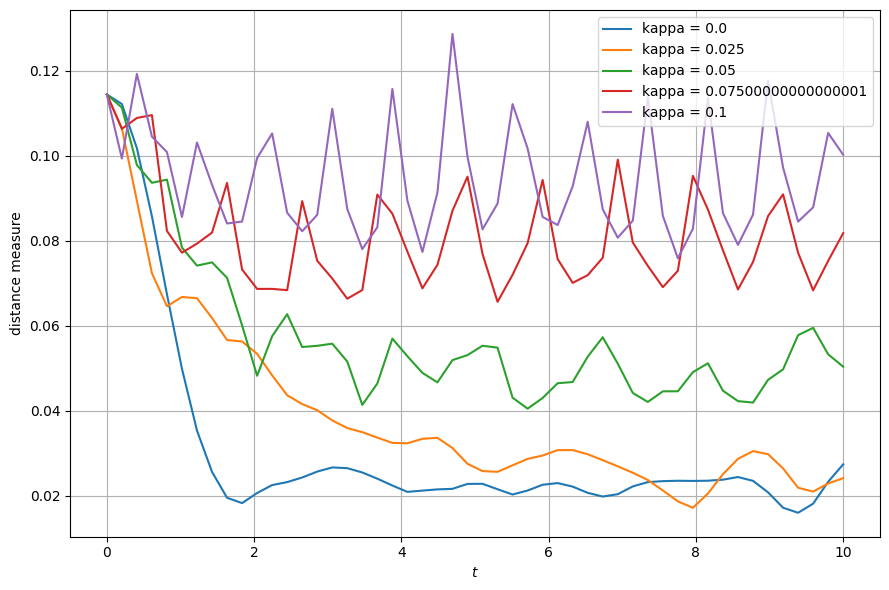

In [25]:
# --- Plotting ---
plt.figure(figsize=(9, 6))

Omega_k = []
gamma_k = []
Q_k = []
rss_k = []

for i, kappa in enumerate(kappa_vals):

    fit = fit_decay_or_oscillation(times, S_all[i])

    Omega_k.append(fit["Omega"])
    gamma_k.append(fit["gamma"])
    Q_k.append(fit["Omega"] / (2*fit["gamma"] + 1e-15))
    rss_k.append(fit["rss"])

    plt.plot(times, D_all[i], label=f'kappa = {kappa}')
    # plt.plot(times, 1-F_all[i], label='Infidelity')
    # plt.plot(times, S_all[i], label='Relative Entropy')

Omega_k = np.array(Omega_k)
gamma_k = np.array(gamma_k)
Q_k = np.array(Q_k)
rss_k = np.array(rss_k)

# plt.plot(kappa_vals, Omega_k, marker='o')
# plt.xlabel(r'$\kappa$')
plt.ylabel(r'Fitted $\Omega(\kappa)$')

plt.xlabel(r'$t$')
plt.ylabel('distance measure')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Conclusion 20/01, 10:30pm: I see that the system does not thermalize as I increase the cavity exciton coupling strength, as I predicted.
# Next, I should look at two things: 1) Make the message pictorially better for the paper; 2) Add other couplings and dephasing


Plotting this for N=1 only. Make changes to the generating code by commenting out the N=2 part and uncommenting the N=1 part.

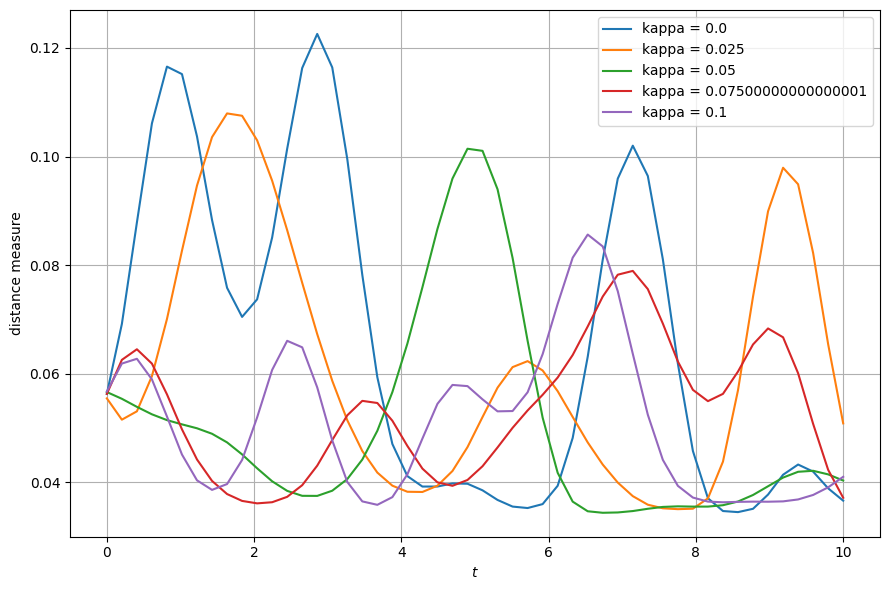

In [ ]:
# --- Plotting ---
plt.figure(figsize=(9, 6))

Omega_k = []
gamma_k = []
Q_k = []
rss_k = []

for i, kappa in enumerate(kappa_vals):

    fit = fit_decay_or_oscillation(times, S_all[i])

    Omega_k.append(fit["Omega"])
    gamma_k.append(fit["gamma"])
    Q_k.append(fit["Omega"] / (2*fit["gamma"] + 1e-15))
    rss_k.append(fit["rss"])

    plt.plot(times, D_all[i], label=f'kappa = {kappa}')
    # plt.plot(times, 1-F_all[i], label='Infidelity')
    # plt.plot(times, S_all[i], label='Relative Entropy')

Omega_k = np.array(Omega_k)
gamma_k = np.array(gamma_k)
Q_k = np.array(Q_k)
rss_k = np.array(rss_k)

# plt.plot(kappa_vals, Omega_k, marker='o')
# plt.xlabel(r'$\kappa$')
plt.ylabel(r'Fitted $\Omega(\kappa)$')

plt.xlabel(r'$t$')
plt.ylabel('distance measure')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Conclusion 20/01, 10:30pm: I see that the system does not thermalize as I increase the cavity exciton coupling strength, as I predicted.
# Next, I should look at two things: 1) Make the message pictorially better for the paper; 2) Add other couplings and dephasing


Failed code below to put dephasing

In [ ]:
# Example 2: L=50, up to N=2 particles
L = 50
max_particles = 2
t_max = 10
num_samples = 50
times = np.linspace(0, t_max, num_samples)
basis, sector_dims = generate_full_basis_structured(L, max_N=max_particles)
print(f"basis length = {len(basis)}")
kappa_vals = np.linspace(0, 0.1, 5)    # N=0 to N=1 or 1 sector coupling constant/exchange interaction/hopping term
keep_sites = [L//2, L//2 - 1, L//2 + 1]
D_all = [0]*len(kappa_vals)
F_all = [0]*len(kappa_vals)
S_all = [0]*len(kappa_vals)
psi_t_all = [0]*len(kappa_vals)
rho_t_all = [None] * len(kappa_vals)
gamma_phi = 1            # Dephasing rate of excitons
dephase_sites = [0, 3, 7]   # Sites that have dephasing happening

print("\n" + "="*60)
print("Basis structure:")
print("="*60)

for N in range(max_particles+1):
    start, end, dim = sector_dims[N]
    print(f"N={N}: basis[{start}:{end}] has {dim} states")

# --- Function to compute observables at a single time ---

# def compute_metrics(t):
#     psi = evecs @ (np.exp(-1j * evals * t) * proj_psi0)
#     rho_full_t = np.outer(psi, psi.conj())
#     rhoA_t = partial_trace_rho_bitbasis(rho_full_t, basis, L, keep_sites, normalize_trace=True)

#     F = fidelity(rhoA_t, rhoA_thermal)
#     D = trace_distance_calc(rhoA_t, rhoA_thermal)
#     S = relative_entropy(rhoA_t, rhoA_thermal)   # S(rhoA_t || rhoA_th)

#     return D, 1-F, S, psi

def compute_metrics_liouville(t):
    # Unitary propagator U(t) = e^{-iHt} using eigendecomposition H = V diag(evals) V^\dagger
    U = evecs @ (np.exp(-1j * evals * t)[:, None] * evecs.conj().T)

    # Initial density matrix rho(0). If you currently use a pure state psi0:
    rho0 = np.outer(psi0, psi0.conj())

    # Liouville / von Neumann evolution: rho(t) = U rho0 U^\dagger
    rho_full_t = U @ rho0 @ U.conj().T

    # Reduced density matrix on keep_sites
    rhoA_t = partial_trace_rho_bitbasis(rho_full_t, basis, L, keep_sites, normalize_trace=True)

    # Distances vs reduced thermal state
    F = fidelity(rhoA_t, rhoA_thermal)
    D = trace_distance_calc(rhoA_t, rhoA_thermal)
    S = relative_entropy(rhoA_t, rhoA_thermal)

    # optional: if you still want to return something like "psi",
    # you can return None or return rho_full_t instead
    return D, 1.0 - F, S, rho_full_t


for i, kappa in enumerate(kappa_vals):
    # --- Hamiltonian and initial state ---
    H = create_block_diagonal_GUE(L, basis, kappa, sector_dims = sector_dims, max_particles = max_particles)

    # # --- Initial state: 1 particle on first site (site index 0) ---
    # N = 1
    # start_1, end_1, dim_1 = sector_dims[N]
    # state_bit = 1 << 0 # particle on site 0
    # idx_in_sector = basis[start_1:end_1].index(state_bit)   # 0..dim_1-1
    # idx_full = start_1 + idx_in_sector  # index in the full basis list
    # psi0 = np.zeros(len(basis), dtype=complex)
    # psi0[idx_full] = 1.0
    # D = len(basis)
    # psi0 = np.ones(D, dtype=complex) / np.sqrt(D)       # Uniform superposition over the basis states

    # # --- Sanity checks ---
    # print("N=1 sector indices:", (start_1, end_1, dim_1))
    # print("Target bitstring:", state_bit, " (binary:", bin(state_bit), ")")
    # print("Index in N=1 sector:", idx_in_sector)
    # print("Index in full basis:", idx_full)

    # --- Initial state: 2 particles on first two sites (sites 0 and 1) ---
    N = 2
    start_2, end_2, dim_2 = sector_dims[N]

    state_bit = (1 << L-1) | (1 << L-2)   # particles on sites 0 and 1
    # equivalently: state_bit = 3

    idx_in_sector = basis[start_2:end_2].index(state_bit)
    idx_full = start_2 + idx_in_sector

    # psi0 = np.zeros(len(basis), dtype=complex)
    # psi0[idx_full] = 1.0
    D = len(basis)
    psi0 = np.ones(D, dtype=complex) / np.sqrt(D)       # Uniform superposition over the basis states

    # --- Thermal state and reduced version ---
    evals, evecs = np.linalg.eigh(H)
    proj_psi0 = evecs.T.conj() @ psi0
    beta_star, _ = find_beta_with_neg_temps(H, psi0, bracket=(-100, 100))
    weights = np.exp(-beta_star * evals)
    weights /= np.sum(weights)
    rho_thermal_full = (evecs * weights[np.newaxis, :]) @ evecs.conj().T
    rhoA_thermal = partial_trace_rho_bitbasis(
        rho_thermal_full, basis, L, keep_sites, normalize_trace=True
    )

    # --- Parallel execution of time evolution ---
    L_ops = make_sz_dephasing_ops_only_N2(basis, sector_dims, L, gamma_phi, sites=dephase_sites)
    rho0 = np.outer(psi0, psi0.conj())  # full density matrix
    rho0_vec = rho0.reshape(-1)
    basis_array = np.array(basis, dtype=np.int64)

    # Use threading backend instead of multiprocessing to avoid pickling issues
    results = []
    for t in times:
        result = compute_metrics_dephasing(t, H, L_ops, rho0_vec, basis_array, L, keep_sites, rhoA_thermal)
        results.append(result)

    # results = Parallel(n_jobs=-1)(delayed(compute_metrics_dephasing)(t, H, L_ops, rho0_vec, basis_array, L, keep_sites, rhoA_thermal) for t in times)

    # --- Unpack results ---
    results_transposed = list(zip(*results))
    D_all[i] = np.array(results_transposed[0])
    F_all[i] = np.array(results_transposed[1])
    S_all[i] = np.array(results_transposed[2])
    rho_t_all[i] = list(results_transposed[3]) 

    for k, rho in enumerate(rho_t_all[i]):
        probs = sector_probabilities_from_rho(rho, sector_dims)
        print(times[k], probs)

    # # After you have psi_t = [psi(t0), psi(t1), ...]
    # dominant = []
    # all_probs = []

    # for k, rho in enumerate(rho_t_all[i]):
    #     probs = sector_probabilities_from_rho(rho, sector_dims)
    #     print(times[k], probs)



# # Optional: check invariance (expect all N=1)
# print("Unique dominant sectors over time:", sorted(set(dominant)))

# # Strong assertion with a tolerance: P(N=1) should be ~1
# tol = 1e-10
# bad = []
# for k, probs in enumerate(all_probs):
#     if abs(probs.get(1, 0.0) - 1.0) > tol:
#         bad.append((k, times[k], probs))
# print(f"Times failing P(N=1)≈1 within tol={tol}: {len(bad)}")
# if bad[:3]:
#     print("First few failures:", bad[:3])

# print(f"reduced rho_thermal = {rhoA_thermal}")
# print("rhoA shape:", rhoA_thermal.shape)
# print("Tr(rhoA) =", np.trace(rhoA_thermal))
# print("Hermiticity check || rhoA - rhoA^†||:", np.linalg.norm(rhoA_thermal - rhoA_thermal.conj().T))